# Baseline Forecasting

Four baseline models will be compared:

- **Naive:** Uses the most recent observed value as the forecast.
- **Seasonal Naive:** Uses the actual value from the same day one week earlier.
- **Weekly SMA:** Uses the average demand from the previous 7 days to smooth daily fluctuations.
- **ETS:** Uses exponential smoothing with weekly seasonality (`seasonal_periods=7`).

If the more advanced statistical model cannot meaningfully outperform the simpler benchmarks, the simpler model is preferred because it is easier to explain, maintain, and implement.

### Forecast Evaluation Metrics

The baseline models are evaluated using three error metrics:

- **MAE:** The average number of units the forecast missed by. Lower values are better.
- **RMSE:** Similar to MAE, but gives more weight to large forecasting errors. Lower values are better.
- **WAPE:** Total forecast error as a percentage of total actual demand. Lower values are better.

When comparing the Naive, Weekly SMA, and ETS models, the preferred model should generally have lower values across all three metrics. If a more complex model only provides a small improvement, the simpler model may still be preferred because it is easier to explain, maintain, and implement.

In [ ]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing



import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

warnings.filterwarnings("ignore")

In [81]:
raw_df = pd.read_parquet("data/processed/category_daily_raw.parquet")
raw_df.head()

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1.0,nan,nan,nan,nan,1,1,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4.0,nan,nan,nan,nan,1,0,1,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [82]:
category_daily = (
    raw_df[["ds", "cat_id", "y"]]
    .groupby(
        ["ds", "cat_id"],
        as_index=False,
        observed=True
    )["y"]
    .sum()
    .sort_values(["cat_id", "ds"])
)

In [83]:
category_daily.to_parquet("data/processed/category_daily.parquet", index=False)

### 1. Naive Baseline Model

**Definition:**  
The Naive model assumes that the next period will be equal to the most recently observed value. It does not account for trend, seasonality, or external factors.

**Mathematical Formula:**

$$
\hat{y}_{t+1} = y_t
$$

*Where:*

- $\hat{y}_{t+1}$ is the forecast for the next period.
- $y_t$ is the most recent observed value.

### 2. Seasonal Naive Baseline Model

**Definition:**  
The Seasonal Naive model forecasts each period using the actual value from the same point in the previous seasonal cycle. For daily retail sales with weekly seasonality, today's forecast is equal to sales from the same day one week earlier.

**Mathematical Formula:**

$$
\hat{y}_t = y_{t-7}
$$

*Where:*

- $\hat{y}_t$ is the forecast for day $t$.
- $y_{t-7}$ is the actual sales value from the same day one week earlier.
- The seasonal period is 7 days.

In [ ]:
# Today's foprecast is yesterday's actuals
category_daily["naive_forecast"] = (
    category_daily
    .groupby("cat_id", observed=True)["y"]
    .shift(1)
)

# Create the 7-day seasonal naive forecast
category_daily["seasonal_naive_forecast"] = (
    category_daily
    .groupby("cat_id", observed=True)["y"]
    .shift(7)
)

In [15]:
naive_results = category_daily.dropna(
    subset=["naive_forecast"]
).copy()

In [35]:
seasonal_naive_results = category_daily.dropna(
    subset=["seasonal_naive_forecast"]
).copy()

In [30]:
# A simple 28 days forecast
test_days = 28

naive_test = (
    naive_results
    .groupby("cat_id", group_keys=False, observed=True)
    .tail(test_days)
    .copy()
)

In [42]:
# same test, same model different window (7 days)
seasonal_naive_test = (
    seasonal_naive_results
    .groupby("cat_id", observed=True, group_keys=False)
    .tail(test_days)
    .copy()
)

In [39]:
# Helper for the forecast error metrics used across all baseline models
def calculate_forecast_metrics(group, forecast_col, actual_col="y"):
    actual = group[actual_col]
    forecast = group[forecast_col]

    # Keep only rows where both actual and forecast values exist
    valid = actual.notna() & forecast.notna()
    actual = actual[valid]
    forecast = forecast[valid]

    mae = np.mean(np.abs(actual - forecast))
    rmse = np.sqrt(np.mean((actual - forecast) ** 2))

    total_actual = actual.abs().sum()

    wape = (
        np.abs(actual - forecast).sum() / total_actual
        if total_actual != 0
        else np.nan
    )

    return pd.Series({
        "MAE": mae,
        "RMSE": rmse,
        "WAPE (%)": wape * 100
    })

In [48]:
naive_metrics = (
    naive_test
    .groupby("cat_id", observed=True)
    .apply(
        lambda group: calculate_forecast_metrics(
            group,
            forecast_col="naive_forecast"
        ),
        include_groups=False
    )
    .reset_index()
)

naive_metrics

,cat_id,MAE,RMSE,WAPE (%)
0,HOBBIES,496.750000,618.235291,12.061430
1,HOUSEHOLD,1160.500000,1515.128540,11.333245
2,FOODS,2941.571533,3665.810547,9.958047


In [44]:
seasonal_naive_metrics = (
    seasonal_naive_test
    .groupby("cat_id", observed=True)
    .apply(
        lambda group: calculate_forecast_metrics(
            group,
            forecast_col="seasonal_naive_forecast"
        ),
        include_groups=False
    )
    .reset_index()
)

seasonal_naive_metrics

,cat_id,MAE,RMSE,WAPE (%)
0,HOBBIES,327.607147,428.310669,7.954526
1,HOUSEHOLD,887.714294,1130.135742,8.669266
2,FOODS,2186.250000,2729.069824,7.401072


In [51]:
print(seasonal_naive_metrics)

      cat_id          MAE         RMSE  WAPE (%)
0    HOBBIES   327.607147   428.310669  7.954526
1  HOUSEHOLD   887.714294  1130.135742  8.669266
2      FOODS  2186.250000  2729.069824  7.401072


In [45]:
# Helper to plot actual sales against any forecast model
def plot_forecasts(
    data,
    forecast_col,
    model_name,
    category_col="cat_id",
    date_col="ds",
    actual_col="y",
    figsize=(12, 5)
):
    for category in data[category_col].dropna().unique():
        category_data = (
            data[data[category_col] == category]
            .sort_values(date_col)
        )

        plt.figure(figsize=figsize)

        plt.plot(
            category_data[date_col],
            category_data[actual_col],
            label="Actual"
        )

        plt.plot(
            category_data[date_col],
            category_data[forecast_col],
            label=f"{model_name} Forecast",
            linestyle="--"
        )

        plt.title(f"{category}: Actual vs. {model_name} Forecast")
        plt.xlabel("Date")
        plt.ylabel("Units Sold")
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

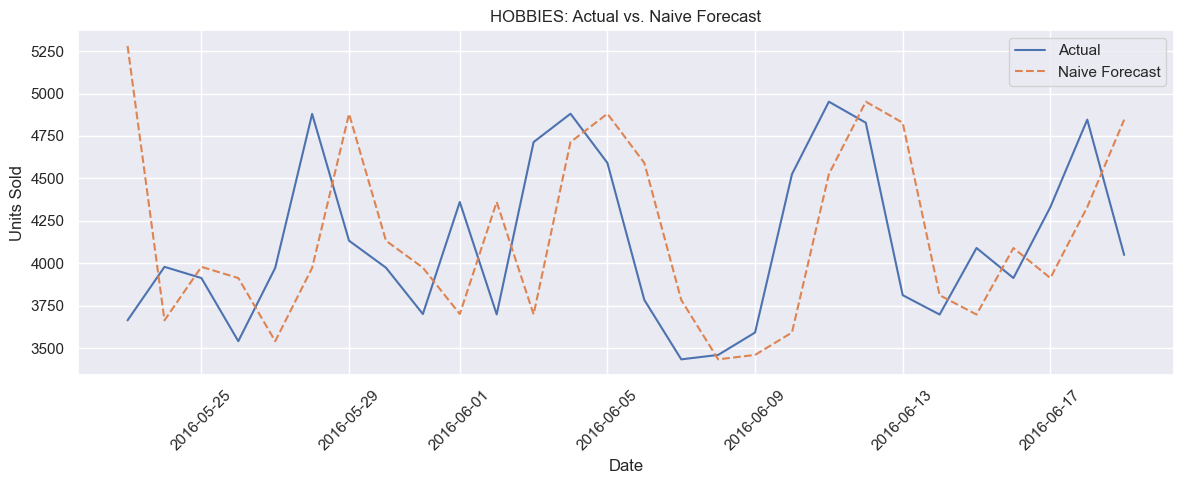

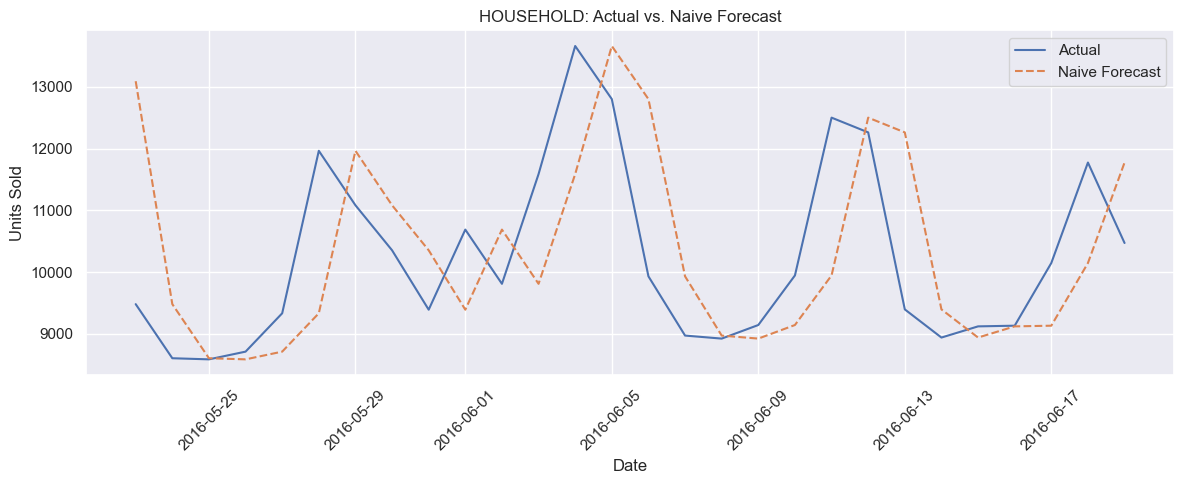

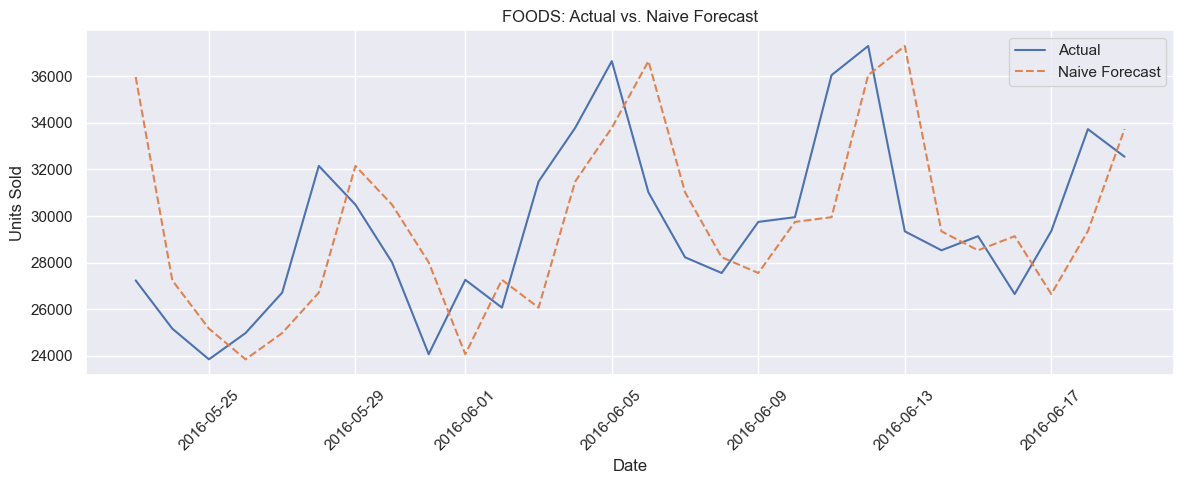

In [46]:
plot_forecasts(
    data=naive_test,
    forecast_col="naive_forecast",
    model_name="Naive"
)

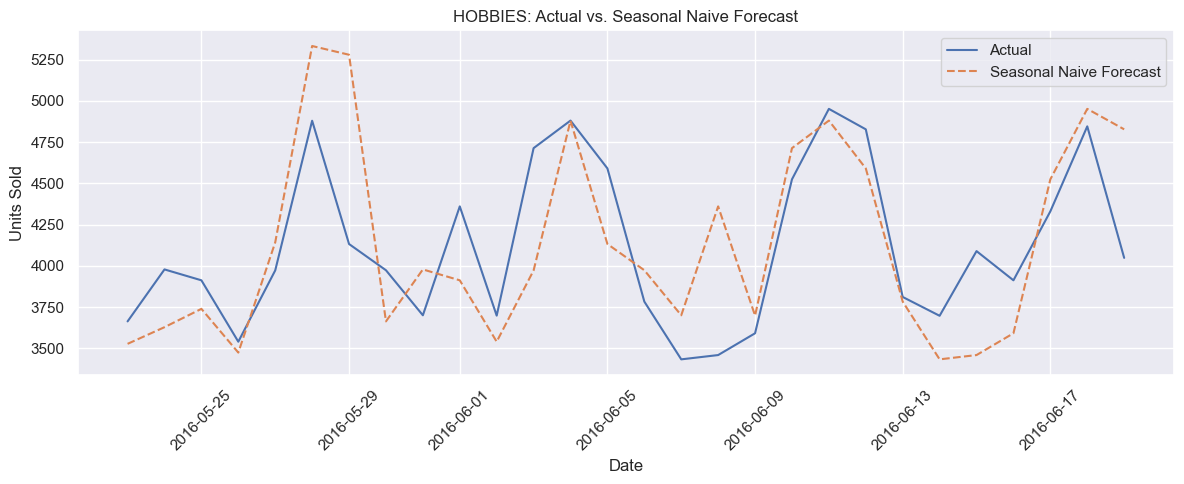

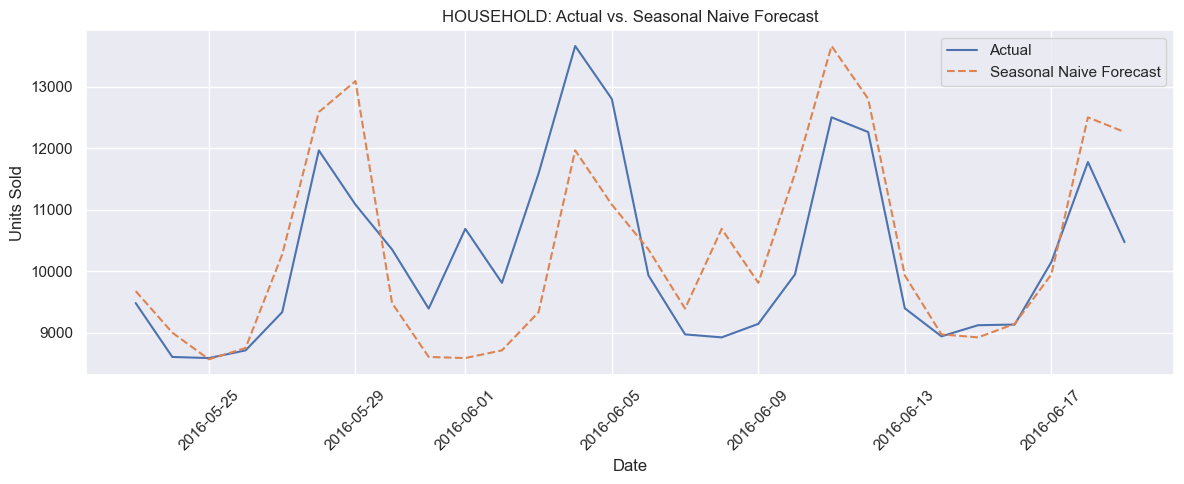

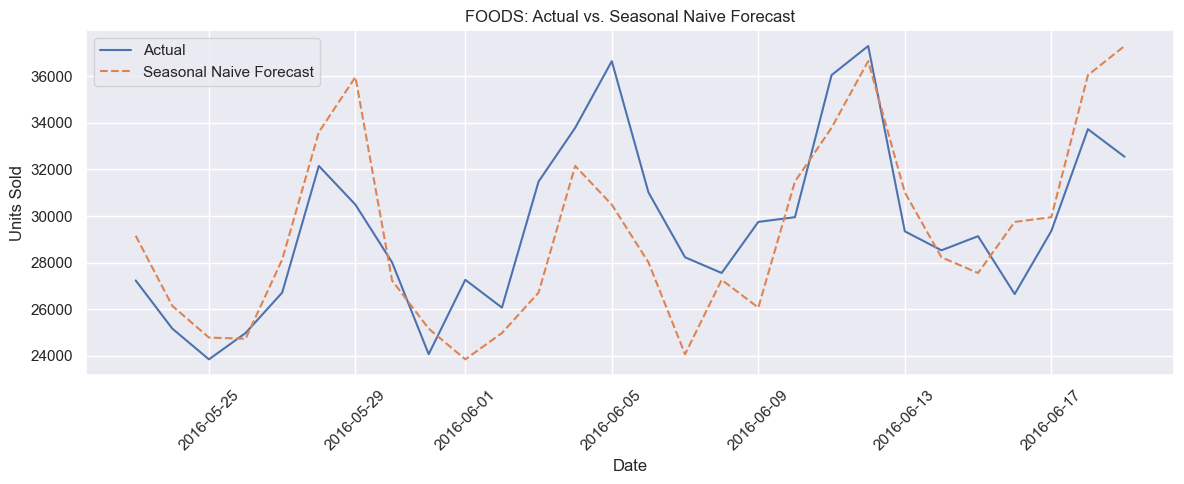

In [47]:
plot_forecasts(
    data=seasonal_naive_test,
    forecast_col="seasonal_naive_forecast",
    model_name="Seasonal Naive"
)

### Seasonal Naive Results

The Seasonal Naive model improved all three error metrics across every category compared with the standard Naive model.

- **HOBBIES:** MAE decreased from **496.75 to 327.61**, RMSE from **618.24 to 428.31**, and WAPE from **12.06% to 7.95%**. This was the largest relative improvement in WAPE.
- **HOUSEHOLD:** MAE decreased from **1,160.50 to 887.71**, RMSE from **1,515.13 to 1,130.14**, and WAPE from **11.33% to 8.67%**.
- **FOODS:** MAE decreased from **2,941.57 to 2,186.25**, RMSE from **3,665.81 to 2,729.07**, and WAPE from **9.96% to 7.40%**. This category had the largest absolute reduction in both MAE and RMSE.

Overall, the results show that using sales from the same day of the previous week captures the weekly demand pattern more effectively than using the previous day's sales.

### 3. Weekly Simple Moving Average Model

**Definition:**  
The 7-day Simple Moving Average forecasts each day using the average sales from the previous seven days.

$$
\hat{y}_t = \frac{y_{t-1}+y_{t-2}+\cdots+y_{t-7}}{7}
$$

This model smooths daily fluctuations while keeping the forecast tied to the most recent week of demand.

In [62]:
# Create the 7-day Simple Moving Average forecast
category_daily["sma_7_forecast"] = (
    category_daily
    .groupby("cat_id", observed=True)["y"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

In [63]:
sma_7_results = category_daily.dropna(
    subset=["sma_7_forecast"]
).copy()

sma_7_test = (
    sma_7_results
    .groupby("cat_id", observed=True, group_keys=False)
    .tail(test_days)
    .copy()
)

In [64]:
sma_7_metrics = (
    sma_7_test
    .groupby("cat_id", observed=True)
    .apply(
        lambda group: calculate_forecast_metrics(
            group,
            forecast_col="sma_7_forecast"
        ),
        include_groups=False
    )
    .reset_index()
)

sma_7_metrics

,cat_id,MAE,RMSE,WAPE (%)
0,HOBBIES,429.627551,494.232636,10.431651
1,HOUSEHOLD,1278.035714,1437.250810,12.481079
2,FOODS,2908.025510,3389.859479,9.844484


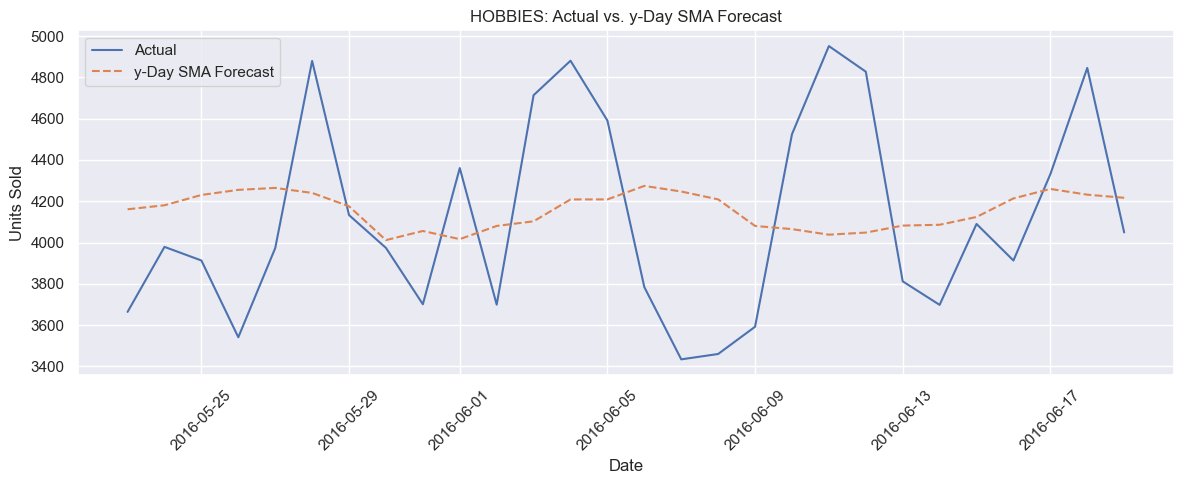

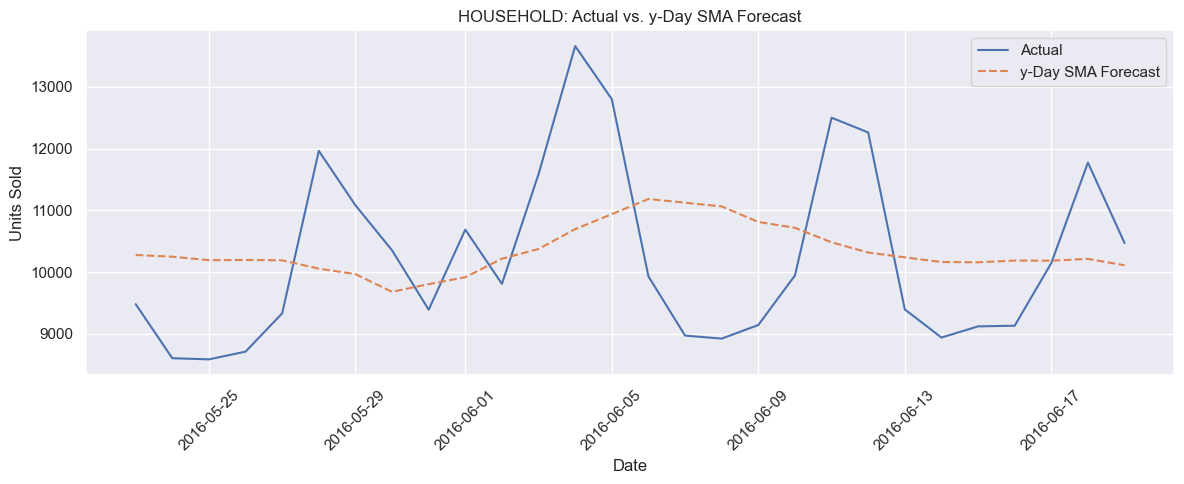

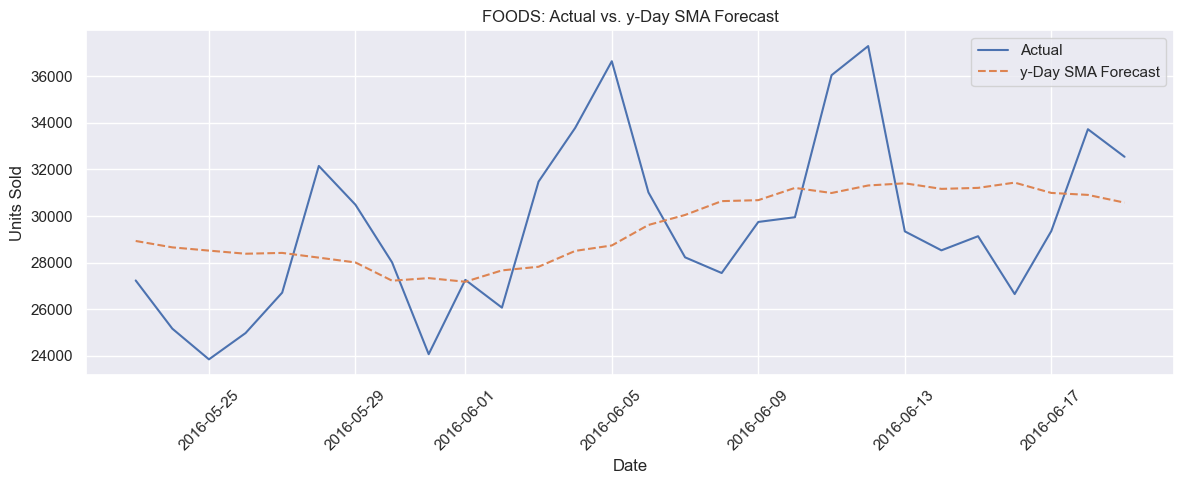

In [65]:
plot_forecasts(
    data=sma_7_test,
    forecast_col="sma_7_forecast",
    model_name=f"y-Day SMA"
)

### 4. Exponential Smoothing (ETS) Model

**Definition:**  
ETS is a time-series forecasting model that updates estimates of the current demand level while giving more weight to recent observations. It can also include trend and seasonality when those patterns are present in the data.

For additive weekly seasonality, the forecast is based on the estimated level and the seasonal effect:

$$
\hat{y}_{t+h} = \ell_t + s_{t+h-m}
$$

*Where:*

- $\ell_t$ is the estimated demand level at time $t$.
- $s_{t+h-m}$ is the seasonal effect for the corresponding day of the week.
- $m = 7$ is the weekly seasonal period.
- $h$ is the forecast horizon.

The level is updated using:

$$
\ell_t = \alpha(y_t - s_{t-m}) + (1-\alpha)\ell_{t-1}
$$

The seasonal component is updated using:

$$
s_t = \gamma(y_t - \ell_t) + (1-\gamma)s_{t-m}
$$

Before fitting the final ETS model, the series will be checked for a meaningful trend component. If the trend is weak, ETS will use level and weekly seasonality only. If a clear and persistent trend is present, an additive trend component will be included.

##### Quick note

### Trend Diagnostic for ETS

Before selecting the ETS specification, STL decomposition is used to separate each category's sales into trend, weekly seasonality, and residual noise.

A linear regression is then fitted to the extracted trend component to measure its direction and magnitude. A trend component will only be included in ETS when the movement is persistent and practically meaningful.


In [66]:
category_daily["is_test"] = (
    category_daily
    .groupby("cat_id", observed=True)
    .cumcount(ascending=False)
    .lt(test_days)
)

train_data = category_daily.loc[
    ~category_daily["is_test"]
].copy()

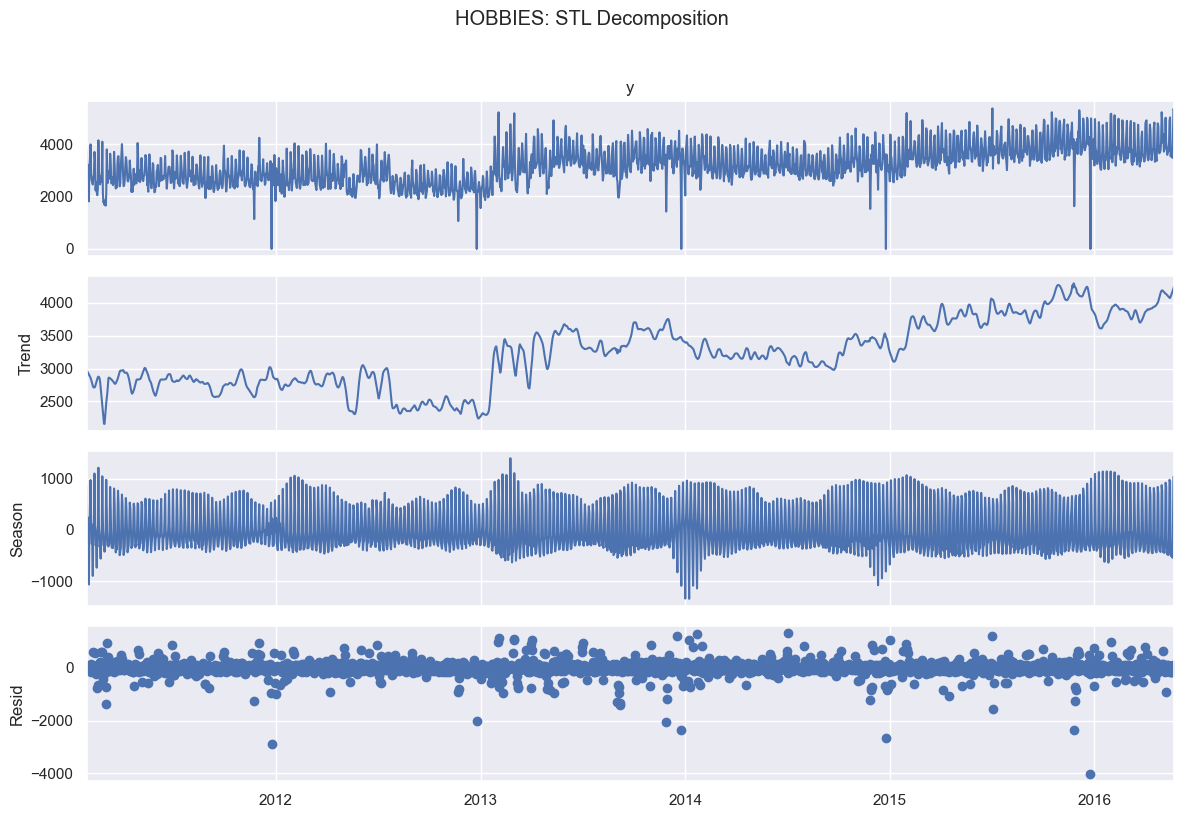

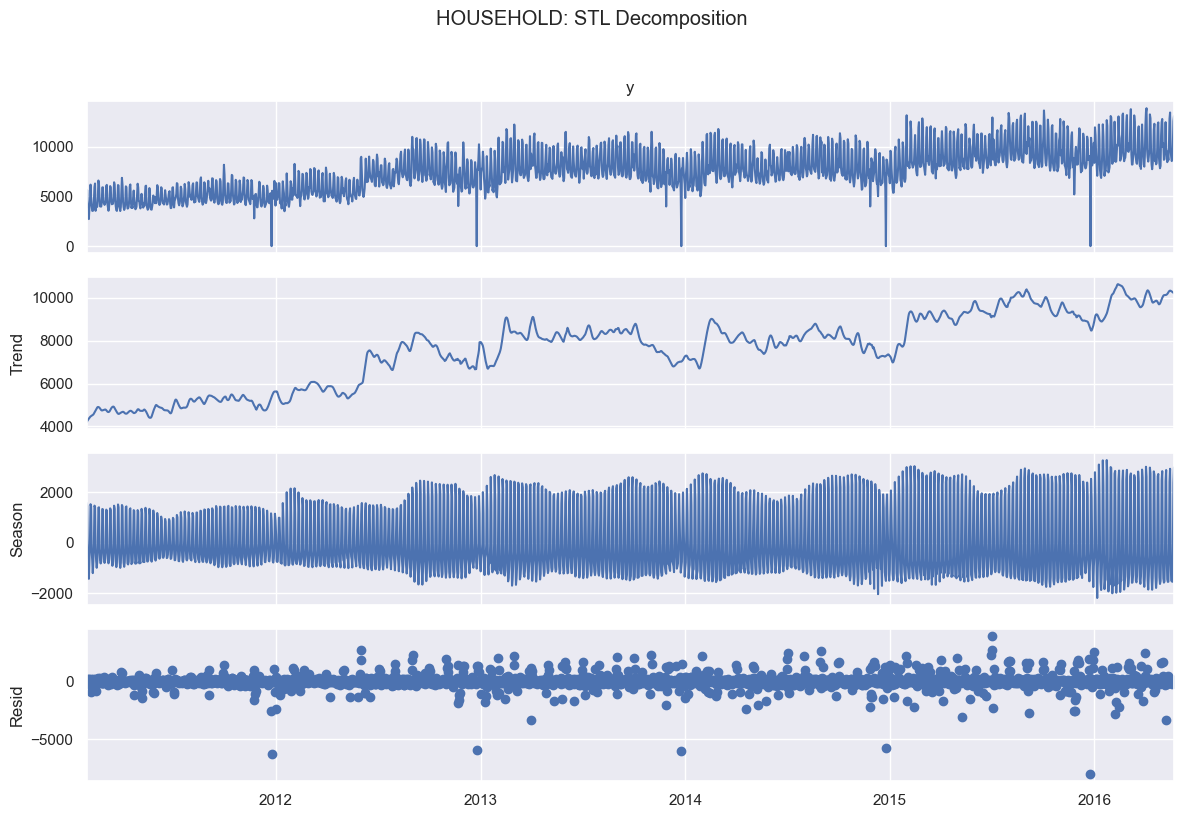

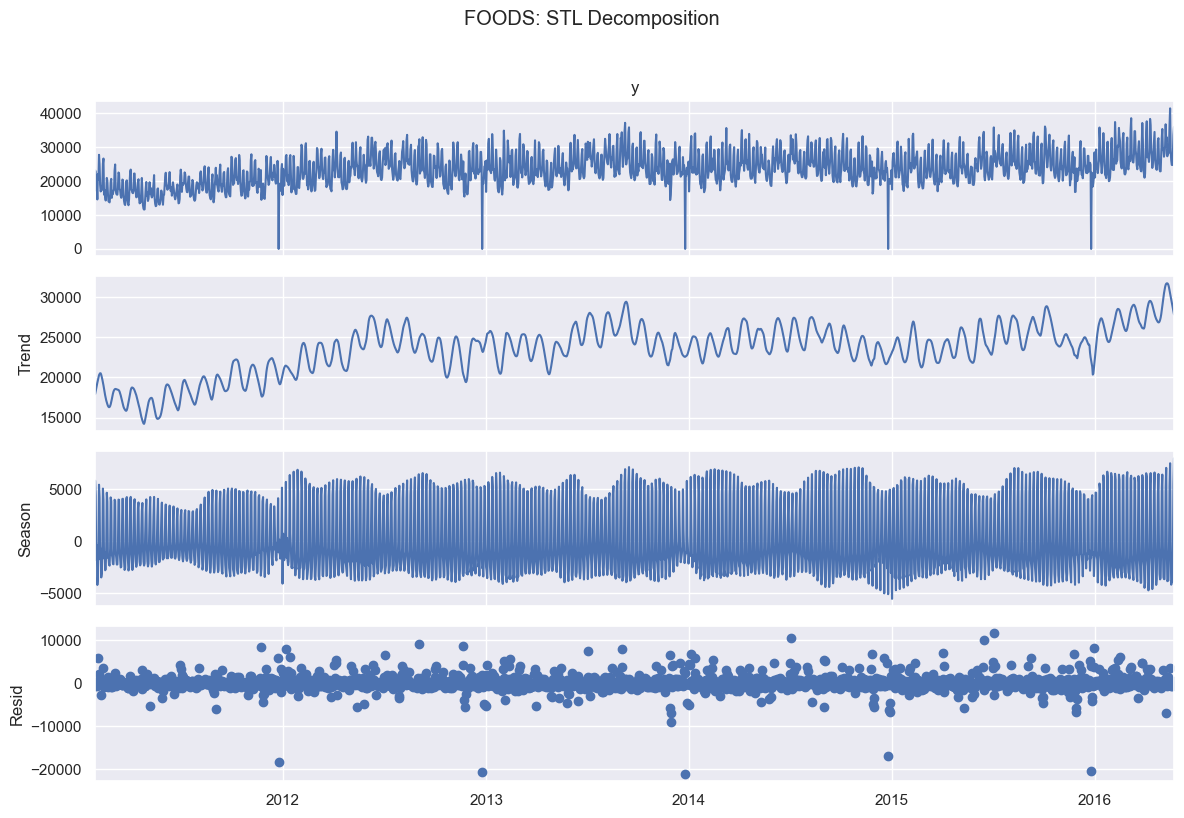

In [69]:
for category, group in train_data.groupby("cat_id", observed=True):
    series = (
        group
        .sort_values("ds")
        .set_index("ds")["y"]
        .astype(float)
    )

    stl_result = STL(
        series,
        period=7,
        robust=True
    ).fit()

    fig = stl_result.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f"{category}: STL Decomposition", y=1.02)
    fig.tight_layout()
    plt.show()

In [71]:
ets_results = []

for category, group in category_daily.groupby("cat_id", observed=True):

    group = group.sort_values("ds").copy()

    train = group.iloc[:-test_days].copy()
    test = group.iloc[-test_days:].copy()

    model = ExponentialSmoothing(
        train["y"].astype(float),
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=7,
        initialization_method="estimated"
    )

    fitted_model = model.fit(optimized=True)

    test["ets_forecast"] = (
        fitted_model
        .forecast(test_days)
        .to_numpy()
    )

    # Demand cannot be negative
    test["ets_forecast"] = test["ets_forecast"].clip(lower=0)

    ets_results.append(test)

ets_test = pd.concat(ets_results, ignore_index=True)

In [72]:
ets_metrics = (
    ets_test
    .groupby("cat_id", observed=True)
    .apply(
        lambda group: calculate_forecast_metrics(
            group,
            forecast_col="ets_forecast"
        ),
        include_groups=False
    )
    .reset_index()
)

ets_metrics

,cat_id,MAE,RMSE,WAPE (%)
0,HOBBIES,245.201182,298.697603,5.953653
1,HOUSEHOLD,552.749898,773.926085,5.398061
2,FOODS,1719.076854,1974.409138,5.819559


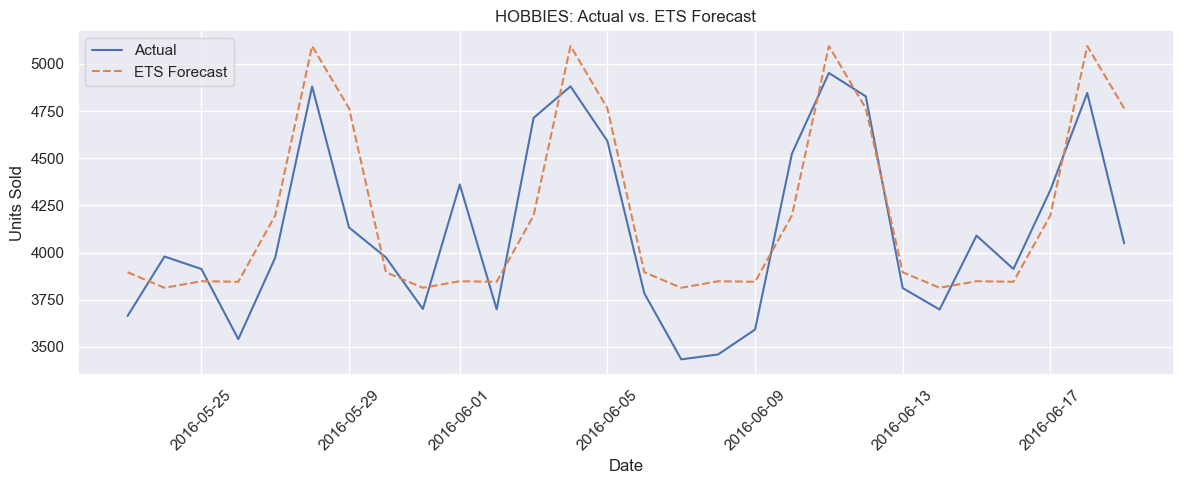

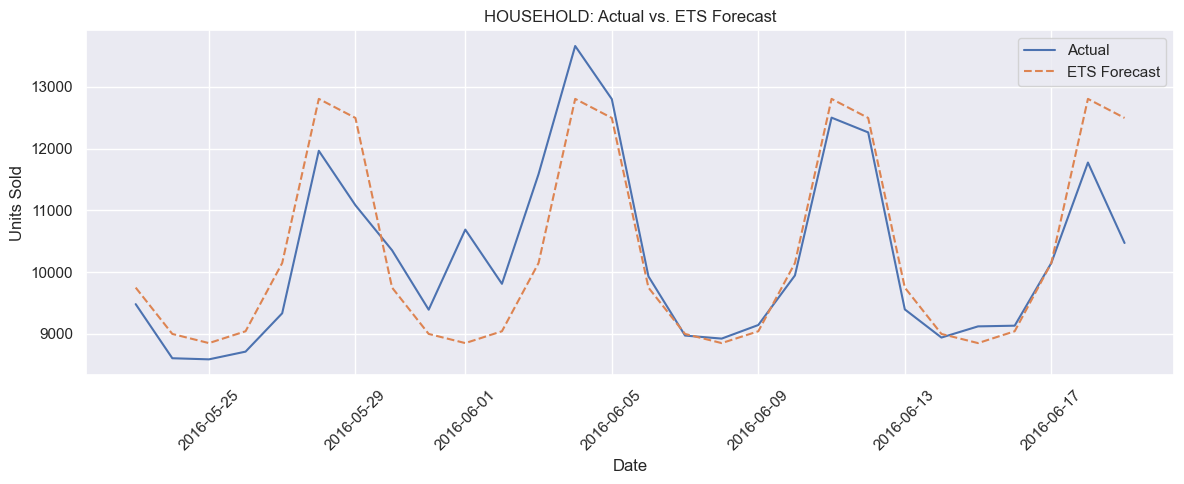

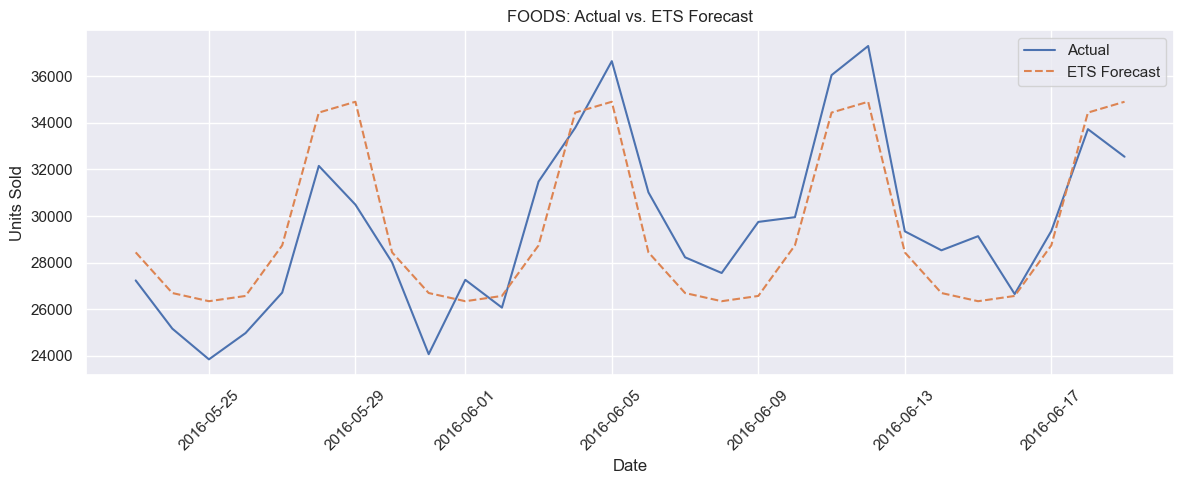

In [73]:
plot_forecasts(
    data=ets_test,
    forecast_col="ets_forecast",
    model_name="ETS"
)

In [74]:
# Add model names before combining the metric tables
naive_metrics["Model"] = "Naive"
seasonal_naive_metrics["Model"] = "Seasonal Naive"
sma_7_metrics["Model"] = "7-Day SMA"
ets_metrics["Model"] = "ETS"

# Combine all model metrics into one table
all_model_metrics = pd.concat(
    [
        naive_metrics,
        seasonal_naive_metrics,
        sma_7_metrics,
        ets_metrics
    ],
    ignore_index=True
)

# Arrange the columns
all_model_metrics = all_model_metrics[
    ["cat_id", "Model", "MAE", "RMSE", "WAPE (%)"]
]

# Round values for easier reading
all_model_metrics = all_model_metrics.round({
    "MAE": 2,
    "RMSE": 2,
    "WAPE (%)": 2
})

all_model_metrics

,cat_id,Model,MAE,RMSE,WAPE (%)
0,HOBBIES,Naive,496.75,618.24,12.06
1,HOUSEHOLD,Naive,1160.50,1515.13,11.33
2,FOODS,Naive,2941.57,3665.81,9.96
3,HOBBIES,Seasonal Naive,327.61,428.31,7.95
4,HOUSEHOLD,Seasonal Naive,887.71,1130.14,8.67
5,FOODS,Seasonal Naive,2186.25,2729.07,7.40
6,HOBBIES,7-Day SMA,429.63,494.23,10.43
7,HOUSEHOLD,7-Day SMA,1278.04,1437.25,12.48
8,FOODS,7-Day SMA,2908.03,3389.86,9.84
9,HOBBIES,ETS,245.20,298.70,5.95


In [75]:
metrics_summary = all_model_metrics.pivot(
    index="cat_id",
    columns="Model",
    values=["MAE", "RMSE", "WAPE (%)"]
)

metrics_summary

MAE                                       RMSE           \
Model     7-Day SMA      ETS    Naive Seasonal Naive 7-Day SMA      ETS   
cat_id                                                                    
HOBBIES      429.63   245.20   496.75         327.61    494.23   298.70   
HOUSEHOLD   1278.04   552.75  1160.50         887.71   1437.25   773.93   
FOODS       2908.03  1719.08  2941.57        2186.25   3389.86  1974.41   

                                   WAPE (%)                              
Model        Naive Seasonal Naive 7-Day SMA   ETS  Naive Seasonal Naive  
cat_id                                                                   
HOBBIES     618.24         428.31     10.43  5.95  12.06           7.95  
HOUSEHOLD  1515.13        1130.14     12.48  5.40  11.33           8.67  
FOODS      3665.81        2729.07      9.84  5.82   9.96           7.40

In [76]:
def plot_metric_comparison(
    metrics_df,
    metric,
    category_col="cat_id",
    model_col="Model",
    figsize=(12, 5)
):
    comparison = metrics_df.pivot(
        index=category_col,
        columns=model_col,
        values=metric
    )

    ax = comparison.plot(
        kind="bar",
        figsize=figsize
    )

    ax.set_title(f"Baseline Model Comparison: {metric}")
    ax.set_xlabel("Category")
    ax.set_ylabel(metric)
    ax.legend(title="Model")
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

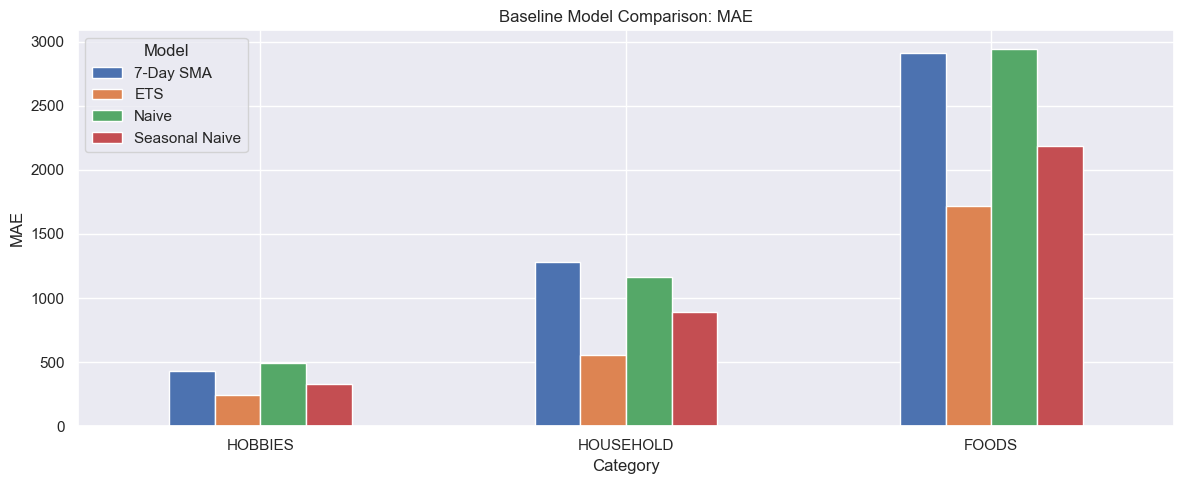

In [77]:
plot_metric_comparison(
    all_model_metrics,
    metric="MAE"
)

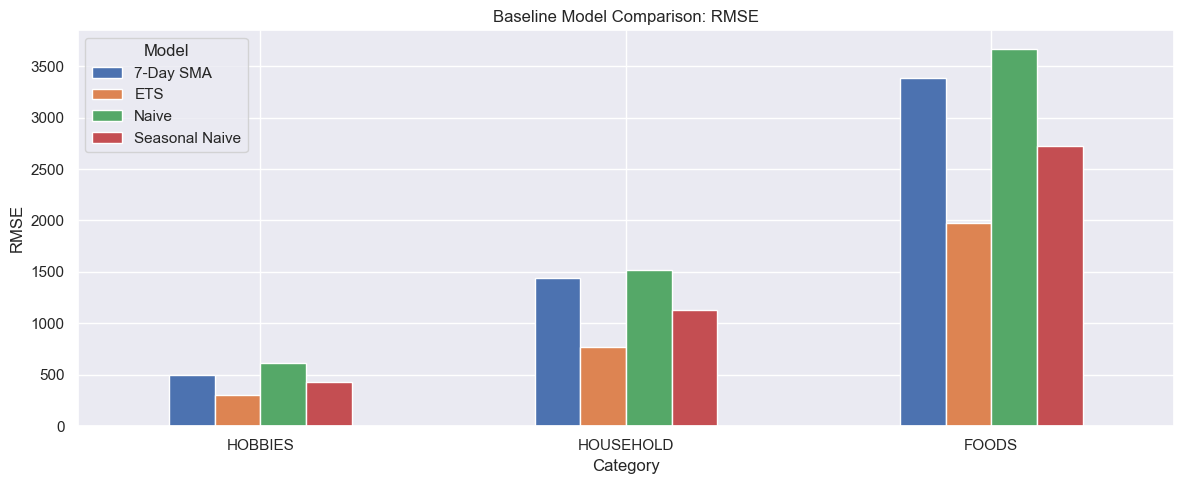

In [80]:
plot_metric_comparison(
    all_model_metrics,
    metric="RMSE"
)

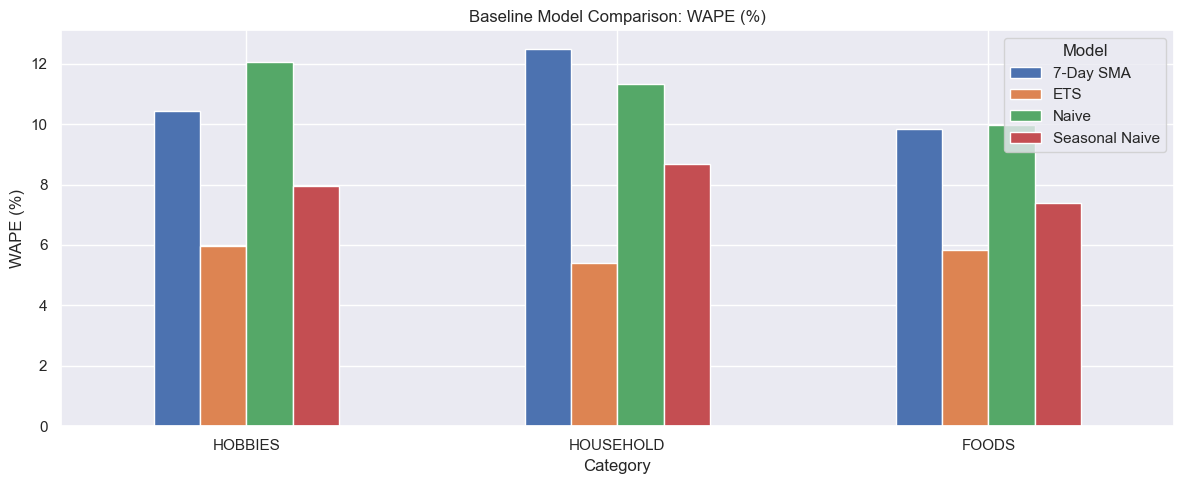

In [79]:
plot_metric_comparison(
    all_model_metrics,
    metric="WAPE (%)"
)

## Baseline Forecasting Conclusion

ETS produced the lowest forecast errors across HOBBIES, HOUSEHOLD, and FOODS, outperforming the Naive, Seasonal Naive, and 7-Day SMA benchmarks.

The Seasonal Naive model improved substantially over the standard Naive model, confirming that weekly seasonality is important in category-level retail demand. However, ETS performed best because it captured both the weekly seasonal pattern and the changing demand level over time.

The 7-Day SMA generally underperformed the Seasonal Naive model because averaging the previous week smooths demand but removes the individual day-of-week pattern.

Based on these results, ETS is selected as the strongest baseline forecasting model. The models will remain fitted to actual unit sales rather than normalized values so the forecasts and errors retain their operational interpretation.